In [13]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os
import seaborn as sns
from pandas import Categorical
import anndata as ann

In [14]:
%matplotlib inline

In [15]:
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from sklearn.metrics import accuracy_score, f1_score


In [16]:
results_har = sc.read_h5ad("combined_har_data.h5ad")

In [17]:
results_har

AnnData object with n_obs × n_vars = 780000 × 5634
    obs: 'cell_type_level1', 'total_counts', 'batch'
    uns: 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

In [18]:
original_labels = pd.read_csv("true_labels.csv")
results_unhar = pd.read_csv("results_unhar.csv")
results_unhar_scetm = pd.read_csv("results_unhar_scetm.csv")


In [19]:
results_har = pd.read_csv("results_har.csv")

In [20]:
results_har

,Unnamed: 0,X_pca
0,0,8
1,1,0
2,2,3
3,3,8
4,4,8
...,...,...
779995,779995,8
779996,779996,7
779997,779997,5
779998,779998,7


In [5]:
original_labels = original_labels.sort_values(by='Unnamed: 0').reset_index(drop=True)
results_unhar = results_unhar.sort_values(by='Unnamed: 0').reset_index(drop=True)
results_unhar_scetm = results_unhar_scetm.sort_values(by='Unnamed: 0').reset_index(drop=True)

In [21]:
results_har = results_har.sort_values(by='Unnamed: 0').reset_index(drop=True)


In [24]:
label_map = {label: idx for idx, label in enumerate(original_labels['perturbation'].unique())}
true_labels_num = original_labels['perturbation'].map(label_map)

In [22]:
def compute_scores(results_df, true_labels, model_name):
    scores = []
    for col in ['X_pca']:
        nmi = normalized_mutual_info_score(true_labels, results_df[col])
        ari = adjusted_rand_score(true_labels, results_df[col])
        scores.append({'Model': model_name, 'Embedding': col, 'NMI': nmi, 'ARI': ari})
    return pd.DataFrame(scores)

In [25]:
scores_har = compute_scores(results_har, true_labels_num, "Harmonized")

In [26]:
scores_har

,Model,Embedding,NMI,ARI
0,Harmonized,X_pca,0.316239,0.156272


In [10]:
scores_unhar = compute_scores(results_unhar, true_labels_num, "Unharmonized")
scores_unhar_scetm = compute_scores(results_unhar_scetm, true_labels_num, "Unharmonized with SCETM")

In [20]:
scores_all = pd.concat([scores_unhar, scores_unhar_scetm], ignore_index=True)


In [23]:
print(scores_all)

                     Model      Embedding       NMI       ARI
0             Unharmonized          X_pca  0.260517  0.136124
1             Unharmonized  X_pca_harmony  0.267607  0.168058
2             Unharmonized    X_scanorama  0.293985  0.181409
3             Unharmonized         X_scvi  0.327579  0.177664
4  Unharmonized with SCETM          X_pca  0.266394  0.130581
5  Unharmonized with SCETM  X_pca_harmony  0.261660  0.121928
6  Unharmonized with SCETM    X_scanorama  0.266299  0.132528
7  Unharmonized with SCETM         X_scvi  0.267026  0.154274


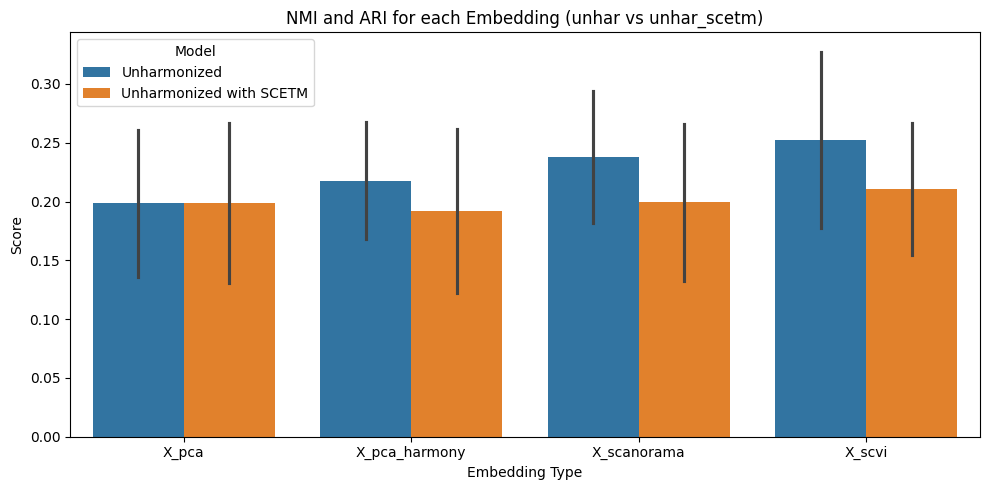

In [24]:
plt.figure(figsize=(10,5))
sns.barplot(data=scores_all.melt(id_vars=['Model', 'Embedding'], value_vars=['NMI','ARI']),
            x='Embedding', y='value', hue='Model')
plt.title("NMI and ARI for each Embedding (unhar vs unhar_scetm)")
plt.ylabel("Score")
plt.xlabel("Embedding Type")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

In [27]:
def map_clusters_to_labels(true_labels, cluster_labels):
    mapping = {}
    df = pd.DataFrame({'true': true_labels, 'cluster': cluster_labels})
    for cluster in df['cluster'].unique():
        majority_label = df[df['cluster'] == cluster]['true'].mode()[0]
        mapping[cluster] = majority_label
    mapped_preds = cluster_labels.map(mapping)
    return mapped_preds, mapping

In [28]:
def compute_f1_acc(results_df, true_labels, model_name):
    results = []
    for col in ['X_pca']:
        mapped_preds, cluster_to_label = map_clusters_to_labels(true_labels, results_df[col])
        acc = accuracy_score(true_labels, mapped_preds)
        f1 = f1_score(true_labels, mapped_preds, average='weighted')  # weighted handles class imbalance
        results.append({'Model': model_name, 'Embedding': col, 'Accuracy': acc, 'F1': f1})
    return pd.DataFrame(results)

In [29]:
f1_acc_har = compute_f1_acc(results_har, true_labels_num, "Harmonized")

In [30]:
f1_acc_har

,Model,Embedding,Accuracy,F1
0,Harmonized,X_pca,0.352317,0.304267


In [29]:
f1_acc_unhar = compute_f1_acc(results_unhar, true_labels_num, "Unharmonized")
f1_acc_unhar_scetm = compute_f1_acc(results_unhar_scetm, true_labels_num, "Unharmonized with SCETM")

In [30]:
f1_acc_all = pd.concat([f1_acc_unhar, f1_acc_unhar_scetm], ignore_index=True)


In [31]:
print(f1_acc_all)


                     Model      Embedding  Accuracy        F1
0             Unharmonized          X_pca  0.304597  0.253015
1             Unharmonized  X_pca_harmony  0.308477  0.245326
2             Unharmonized    X_scanorama  0.329221  0.254797
3             Unharmonized         X_scvi  0.354255  0.266372
4  Unharmonized with SCETM          X_pca  0.278747  0.204339
5  Unharmonized with SCETM  X_pca_harmony  0.280895  0.207960
6  Unharmonized with SCETM    X_scanorama  0.289141  0.227469
7  Unharmonized with SCETM         X_scvi  0.296023  0.214130


In [32]:
all_scores = scores_all.merge(f1_acc_all, on=['Model', 'Embedding'])

In [33]:
all_scores

,Model,Embedding,NMI,ARI,Accuracy,F1
0,Unharmonized,X_pca,0.260517,0.136124,0.304597,0.253015
1,Unharmonized,X_pca_harmony,0.267607,0.168058,0.308477,0.245326
2,Unharmonized,X_scanorama,0.293985,0.181409,0.329221,0.254797
3,Unharmonized,X_scvi,0.327579,0.177664,0.354255,0.266372
4,Unharmonized with SCETM,X_pca,0.266394,0.130581,0.278747,0.204339
5,Unharmonized with SCETM,X_pca_harmony,0.261660,0.121928,0.280895,0.207960
6,Unharmonized with SCETM,X_scanorama,0.266299,0.132528,0.289141,0.227469
7,Unharmonized with SCETM,X_scvi,0.267026,0.154274,0.296023,0.214130


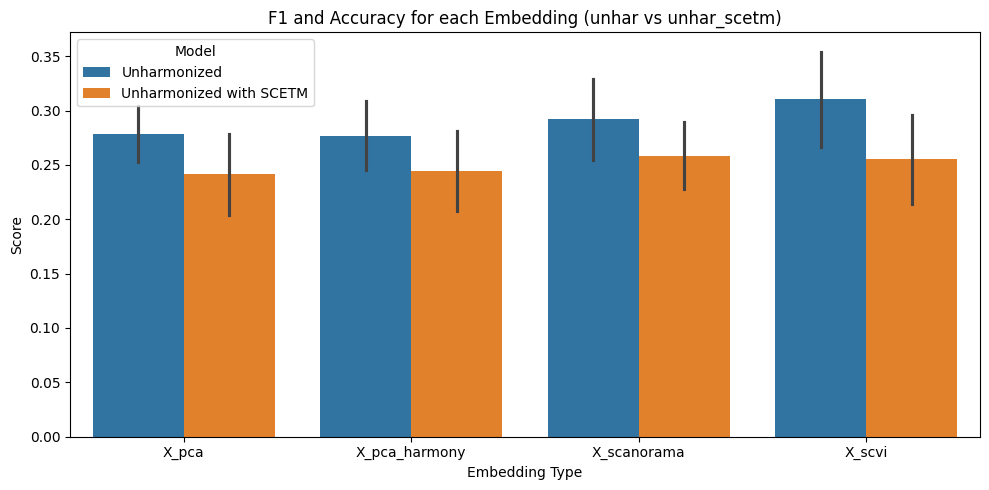

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.barplot(data=f1_acc_all.melt(id_vars=['Model','Embedding'], value_vars=['Accuracy','F1']),
            x='Embedding', y='value', hue='Model')
plt.title("F1 and Accuracy for each Embedding (unhar vs unhar_scetm)")
plt.ylabel("Score")
plt.xlabel("Embedding Type")
plt.legend(title="Model")
plt.tight_layout()
plt.show()



=== Combined Metrics ===
         Model      Embedding       NMI       ARI  Accuracy        F1
0        unhar          X_pca  0.260517  0.136125  0.304597  0.253015
1        unhar  X_pca_harmony  0.267607  0.168058  0.308477  0.245326
2        unhar    X_scanorama  0.293985  0.181409  0.329221  0.254797
3        unhar         X_scvi  0.327579  0.177664  0.354255  0.266372
4  unhar_scetm          X_pca  0.266394  0.130581  0.278747  0.204339
5  unhar_scetm  X_pca_harmony  0.261660  0.121928  0.280895  0.207960
6  unhar_scetm    X_scanorama  0.266299  0.132528  0.289141  0.227469
7  unhar_scetm         X_scvi  0.267026  0.154274  0.296023  0.214130


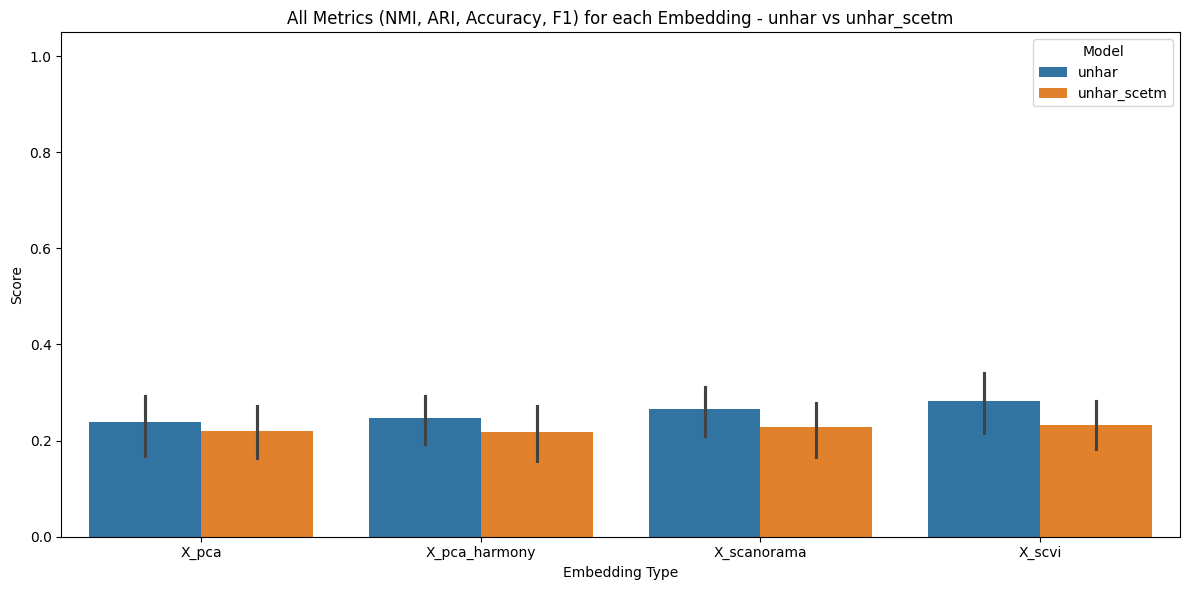

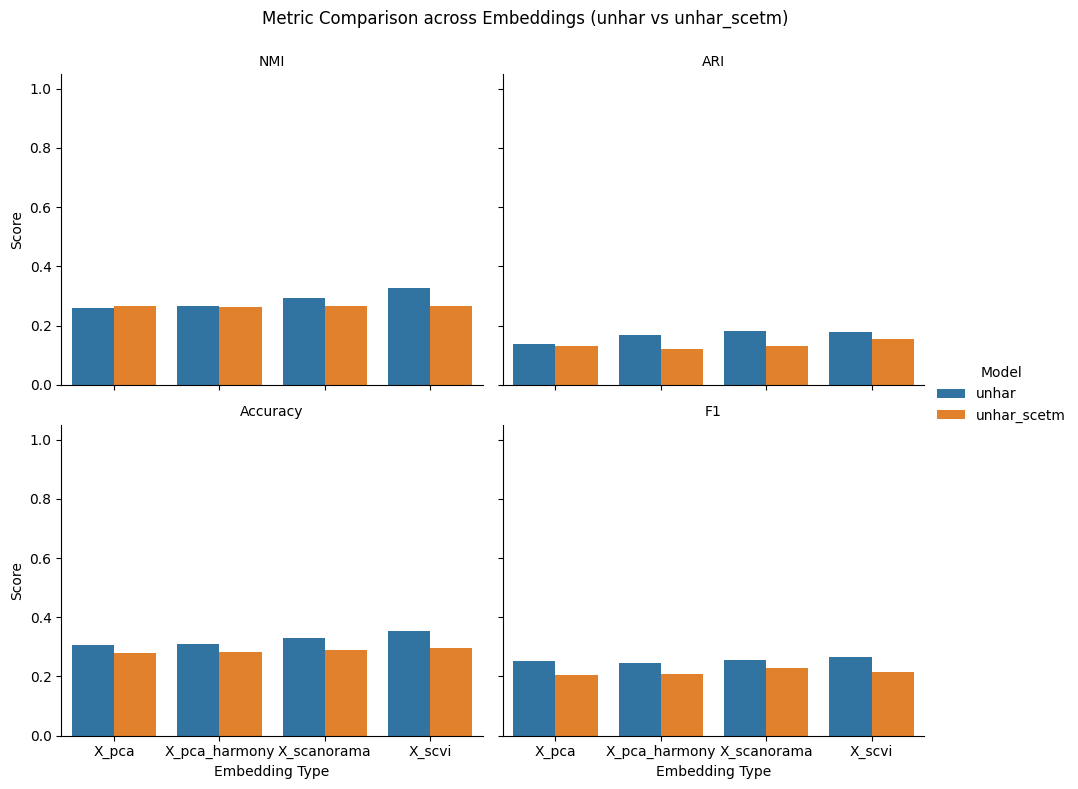

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    normalized_mutual_info_score,
    adjusted_rand_score,
    accuracy_score,
    f1_score,
)

# === Load the data ===
original_labels = pd.read_csv("true_labels.csv")
results_unhar = pd.read_csv("results_unhar.csv")
results_unhar_scetm = pd.read_csv("results_unhar_scetm.csv")

# === Preprocess ===
original_labels = original_labels.sort_values(by="Unnamed: 0").reset_index(drop=True)
results_unhar = results_unhar.sort_values(by="Unnamed: 0").reset_index(drop=True)
results_unhar_scetm = results_unhar_scetm.sort_values(by="Unnamed: 0").reset_index(drop=True)

# Encode string labels into integers
label_map = {label: idx for idx, label in enumerate(original_labels["perturbation"].unique())}
true_labels_num = original_labels["perturbation"].map(label_map)

# === Helper functions ===
def compute_nmi_ari(results_df, true_labels, model_name):
    out = []
    for col in ["X_pca", "X_pca_harmony", "X_scanorama", "X_scvi"]:
        nmi = normalized_mutual_info_score(true_labels, results_df[col])
        ari = adjusted_rand_score(true_labels, results_df[col])
        out.append({"Model": model_name, "Embedding": col, "NMI": nmi, "ARI": ari})
    return pd.DataFrame(out)


def map_clusters_to_labels(true_labels, cluster_labels):
    mapping = {}
    df = pd.DataFrame({"true": true_labels, "cluster": cluster_labels})
    for cluster in df["cluster"].unique():
        majority_label = df[df["cluster"] == cluster]["true"].mode()[0]
        mapping[cluster] = majority_label
    mapped_preds = cluster_labels.map(mapping)
    return mapped_preds, mapping


def compute_f1_acc(results_df, true_labels, model_name):
    out = []
    for col in ["X_pca", "X_pca_harmony", "X_scanorama", "X_scvi"]:
        mapped_preds, _ = map_clusters_to_labels(true_labels, results_df[col])
        acc = accuracy_score(true_labels, mapped_preds)
        f1 = f1_score(true_labels, mapped_preds, average="weighted")
        out.append({"Model": model_name, "Embedding": col, "Accuracy": acc, "F1": f1})
    return pd.DataFrame(out)


# === Compute all metrics ===
scores_unhar = compute_nmi_ari(results_unhar, true_labels_num, "unhar")
scores_unhar_scetm = compute_nmi_ari(results_unhar_scetm, true_labels_num, "unhar_scetm")

f1_acc_unhar = compute_f1_acc(results_unhar, true_labels_num, "unhar")
f1_acc_unhar_scetm = compute_f1_acc(results_unhar_scetm, true_labels_num, "unhar_scetm")

# Merge everything
metrics_all = (
    pd.concat([scores_unhar, scores_unhar_scetm])
    .merge(pd.concat([f1_acc_unhar, f1_acc_unhar_scetm]),
           on=["Model", "Embedding"])
)

print("\n=== Combined Metrics ===")
print(metrics_all)

# === Prepare for plotting ===
metrics_melted = metrics_all.melt(
    id_vars=["Model", "Embedding"],
    value_vars=["NMI", "ARI", "Accuracy", "F1"],
    var_name="Metric",
    value_name="Score"
)

# === Combined Plot (all metrics together) ===
plt.figure(figsize=(12, 6))
sns.barplot(
    data=metrics_melted,
    x="Embedding",
    y="Score",
    hue="Model",
    palette="tab10"
)
plt.title("All Metrics (NMI, ARI, Accuracy, F1) for each Embedding - unhar vs unhar_scetm")
plt.xlabel("Embedding Type")
plt.ylabel("Score")
plt.legend(title="Model")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

# === Faceted Plot (separate subplot per metric) ===
g = sns.catplot(
    data=metrics_melted,
    x="Embedding",
    y="Score",
    hue="Model",
    col="Metric",
    kind="bar",
    palette="tab10",
    col_wrap=2,
    height=4,
    aspect=1.2
)
g.set_titles("{col_name}")
g.set_axis_labels("Embedding Type", "Score")
g.set(ylim=(0, 1.05))
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Metric Comparison across Embeddings (unhar vs unhar_scetm)")
plt.show()


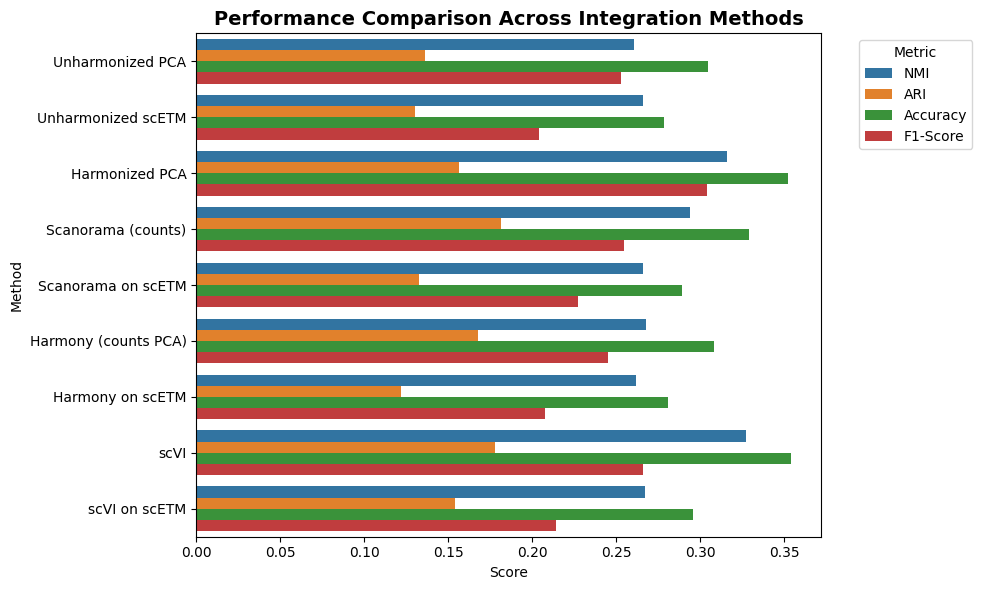

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Data ---
data = {
    'Method': [
        'Unharmonized PCA', 'Unharmonized scETM',
        'Harmonized PCA', 'Scanorama (counts)',
        'Scanorama on scETM', 'Harmony (counts PCA)',
        'Harmony on scETM', 'scVI', 'scVI on scETM'
    ],
    'NMI': [0.2605, 0.2663, 0.316239, 0.2939, 0.2662, 0.2676, 0.2616, 0.3275, 0.2670],
    'ARI': [0.1361, 0.1305, 0.156272, 0.1814, 0.1325, 0.1680, 0.1219, 0.1776, 0.1542],
    'Accuracy': [0.3045, 0.2787, 0.352317, 0.3292, 0.2891, 0.3084, 0.2808, 0.3542, 0.2960],
    'F1-Score': [0.2530, 0.2043, 0.304267, 0.2547, 0.2274, 0.2453, 0.2079, 0.2663, 0.2141]
}

df = pd.DataFrame(data)

# --- Melt to long format for Seaborn ---
df_melted = df.melt(id_vars='Method', var_name='Metric', value_name='Score')

# --- Plot ---
plt.figure(figsize=(10, 6))
sns.barplot(data=df_melted, y='Method', x='Score', hue='Metric')

plt.title('Performance Comparison Across Integration Methods', fontsize=14, weight='bold')
plt.xlabel('Score')
plt.ylabel('Method')
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
